In [1]:
import bacco
import numpy as np
import h5py
import matplotlib.pyplot as plt
from scipy.spatial import KDTree

In [2]:
import os
os.chdir("/lscratch/fgmaion/MTNG-resims/src")
import utils
import merger_tree_tools as mgt

In [3]:
%load_ext autoreload
%autoreload 2

In [4]:
def q_pos(mbID, npart=4320, BoxSize=500, mtng=False, idstart=0):
    
    if mtng:
        mbID[np.where(mbID>=1)] -= 20155392000
        mbID[np.where(mbID<1)] += 80621568000

    q = np.zeros(mbID.shape + (3,), dtype=np.float32)

    q[..., 0] = (mbID - idstart) // npart**2
    q[..., 1] = ( (mbID - idstart) // npart) % npart
    q[..., 2] = (mbID - idstart) % npart

    # normalize correctly
    q *= (BoxSize / npart)

    return q

In [5]:
def zoom_q_pos(mbID, npart=4320, BoxSize=500, mtng=False, idstart=0):

    sigma8 = 0.8159 #CHECK ME
    ns     = 0.9667 #CHECK ME
    tau    = 0.0965 #CHECK ME

    # load zoom ics
    base_ics = "/cosmos_storage/data_sharing/MN5_resims/ICs_1pmbin_2160/output/"
    zoom_ics = bacco.Simulation(basedir=base_ics, halo_file="groups_000/fof_subhalo_tab_000", dm_file="snapdir_000/snapshot_ics_000", sim_format='TNG500', fixedPk=True, use_orphans=False,\
                        tau=tau, ns=ns, sigma8=sigma8, use_ids=False)
    
    q = np.zeros(mbID.shape + (3,), dtype=np.float32)

    q[..., 0] = (mbID - idstart) // npart**2
    q[..., 1] = ( (mbID - idstart) // npart) % npart
    q[..., 2] = (mbID - idstart) % npart

    # normalize correctly
    q *= (BoxSize / npart)

    return q

### Load the Zoom

In [5]:
base = "/cosmos_storage/data_sharing/MN5_resims/fiducial/hydro_output/"
base_dm = "/cosmos_storage/data_sharing/tmp_resims/1080-A/level1/1pmbin_2160/gro_output"

sigma8 = 0.8159 #CHECK ME
ns     = 0.9667 #CHECK ME
tau    = 0.0965 #CHECK ME

snap = 264
zoom = bacco.Simulation(basedir=base, halo_file="groups_{:03d}/fof_subhalo_tab_{:03d}".format(snap,snap), dm_file="snapdir_{:03d}/snapshot_{:03d}".format(snap,snap), sim_format='TNG500', fixedPk=True, use_orphans=False,\
                        tau=tau, ns=ns, sigma8=sigma8, tree_file="groups_{:03d}/subhalo_prog_{:03d}".format(snap,snap), numpart=4320**3)

print(zoom.header['Redshift'])

2024-08-27 14:42:30,650 bacco.sims : Initialising simulation Default


2024-08-27 14:42:30,651 bacco.sims : try /cosmos_storage/data_sharing/MN5_resims/fiducial/hydro_output/snapdir_264/snapshot_264
2024-08-27 14:42:30,670 bacco.sims : Loading /cosmos_storage/data_sharing/MN5_resims/fiducial/hydro_output/snapdir_264/snapshot_264
2024-08-27 14:42:30,675 bacco.sims : Creating snapshot array from /cosmos_storage/data_sharing/MN5_resims/fiducial/hydro_output/snapdir_264/snapshot_264 because: exists=True, newer=False
2024-08-27 14:42:30,676 bacco.sims : File exists but without write permission. We will use the existing snaplist.txt file.
/scratch/fgmaion/baccogit/bacco/simulation.py:1401: UserWarning: loadtxt: input contained no data: "/cosmos_storage/data_sharing/MN5_resims/fiducial/hydro_output//snaplist.txt"
  tab = np.loadtxt(self.BaseDir + '/snaplist.txt')
2024-08-27 14:42:30,681 bacco.sims : Warning: Empty snaplist.txt
2024-08-27 14:42:30,682 bacco.sims : ...done in 0.0246 s


4.440892098500626e-16


### Load the Original Sim

In [7]:
mtng = bacco.utils.load_MTNG(adr="/cosmos_storage/simulations/MTNG/", snap=snap)
mtng.fof['halo_pos'][:,0] = (mtng.fof['halo_pos'][:,0] - 125) % 500
mtng.sub['pos'][:,0] = (mtng.sub['pos'][:,0] - 125) % 500

print(mtng.header['Redshift'])

2024-08-27 14:42:59,469 bacco.sims : Initialising simulation Default
2024-08-27 14:42:59,470 bacco.sims : try /cosmos_storage/simulations/MTNG/groups_264/fof_subhalo_tab_264
2024-08-27 14:42:59,472 bacco.sims : Loading /cosmos_storage/simulations/MTNG/groups_264/fof_subhalo_tab_264
2024-08-27 14:42:59,478 bacco.sims : Creating snapshot array from /cosmos_storage/simulations/MTNG/groups_264/fof_subhalo_tab_264 because: exists=True, newer=False
/scratch/fgmaion/baccogit/bacco/simulation.py:1401: UserWarning: loadtxt: input contained no data: "/cosmos_storage/simulations/MTNG//snaplist.txt"
  tab = np.loadtxt(self.BaseDir + '/snaplist.txt')
2024-08-27 14:42:59,496 bacco.sims : Warning: Empty snaplist.txt
2024-08-27 14:42:59,497 bacco.sims : ...done in 0.00894 s
2024-08-27 14:42:59,501 bacco.sims : Reading 98233510 items for GroupPos
2024-08-27 14:43:05,739 bacco.sims : Reading 90246895 items for SubhaloPos


4.440892098500626e-16


### Cross-Match Selected Halos

In [8]:
with open("/lscratch/fgmaion/MTNG-resims/halo_selections/2160-A/hydro_halo_sel_1pmbin.txt") as f:
    final_sel = []

    for line in f.readlines():
        final_sel.append(int(line.split()[0]))

final_sel = np.array(final_sel)

### Now cross-match those at same redshift

In [9]:
psel = np.where(zoom.fof['halo_m200b']>0)[0]

X1 = zoom.fof['halo_pos'][psel]
X2 = mtng.fof['halo_pos'][final_sel]

kdt = KDTree(X1, boxsize=500)
dist, ind = kdt.query(X2, k=100)

ind[np.where(dist==np.inf)] = -1

2024-08-27 14:43:19,659 bacco.sims : Reading 139825 items for Group_M_Mean200


2024-08-27 14:43:19,686 bacco.sims : Reading 139825 items for GroupPos


In [10]:
M1 = 1e10 * zoom.fof['halo_m200b'][psel][ind]
M2 = 1e10 * mtng.fof['halo_m200b'][final_sel]

pos1 = np.transpose(zoom.fof['halo_pos'][psel][ind], (2,0,1))
pos2 = mtng.fof['halo_pos'][final_sel].T

vmax_1 = zoom.sub['vmax'][zoom.fof['halo_firstsub'][psel][ind]]
vmax_2 = mtng.sub['vmax'][mtng.fof['halo_firstsub'][final_sel]]


2024-08-27 14:43:20,345 bacco.sims : Reading 98233510 items for Group_M_Mean200


2024-08-27 14:43:23,327 bacco.sims : Reading 74741 items for SubhaloVmax
2024-08-27 14:43:23,344 bacco.sims : Reading 139825 items for halo_firstsub
2024-08-27 14:43:23,381 bacco.sims : Reading 90246895 items for SubhaloVmax
2024-08-27 14:43:26,238 bacco.sims : Reading 98233510 items for halo_firstsub


In [11]:
def metric(m1,m2,v1,v2,dist,a,b,c):

    #d_m = np.abs(np.log10(m1[...,np.newaxis]/m2))
    #d_v = np.abs(v1[...,np.newaxis]-v2)

    d_m = np.abs( (1 - m1[...,np.newaxis]/m2)/0.2 )
    d_v = np.abs( (1 - v1[...,np.newaxis]/v2)/0.2 )

    return dist*a + d_m*b + d_v*c


In [12]:
d = metric(M2,M1,vmax_2,vmax_1,dist,100,1,1)

xmatch = np.zeros(len(M1), dtype=int)
dmatch = np.zeros(len(M1))
metr = np.zeros(len(M1))

for i in range(len(M1)):
    metr[i] = d[i].min()
    xmatch[i] = ind[i,np.where(d[i]==d[i].min())[0][0]]
    dmatch[i] = dist[i,np.where(d[i]==d[i].min())[0][0]]

In [13]:
ihalo =350

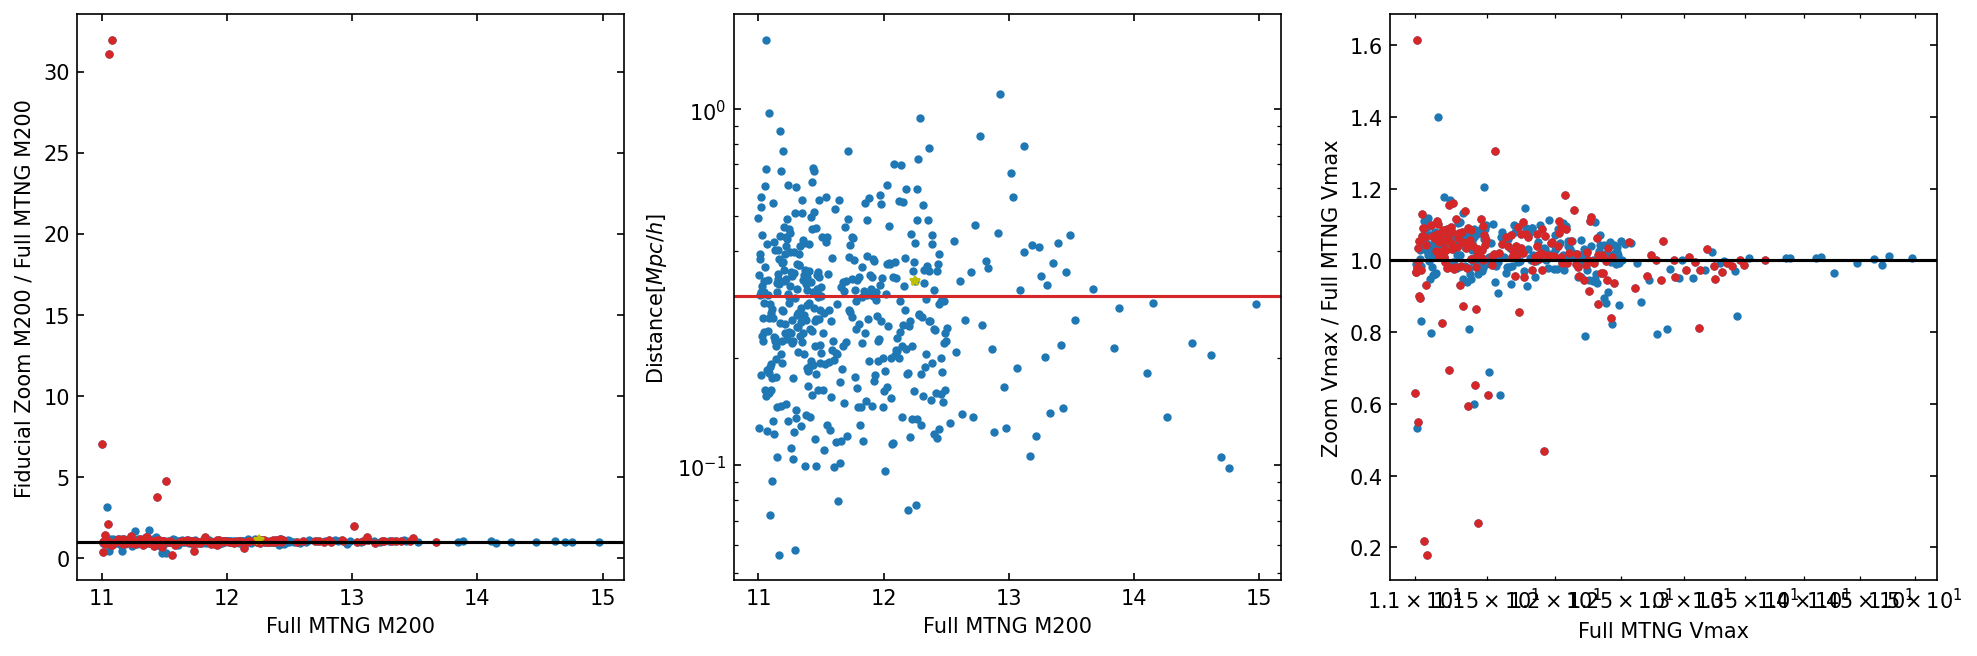

In [14]:
fig, ax = plt.subplots(1, 3, dpi=150, figsize=(16,5))

w = np.where(dmatch>0.3)

Xarr = np.log10(1e10*mtng.fof['halo_m200b'][final_sel])
Yarr = (zoom.fof['halo_m200b'][psel[xmatch]] / mtng.fof['halo_m200b'][final_sel])

Xarr_out = np.log10(1e10*mtng.fof['halo_m200b'][final_sel][w])
Yarr_out = (zoom.fof['halo_m200b'][psel[xmatch]][w] / mtng.fof['halo_m200b'][final_sel][w])

ax[0].plot(Xarr, Yarr, marker='o', color='C0', ms=3, ls='')
ax[0].plot(Xarr_out, Yarr_out, marker='o', color='C3', ms=3, ls='')

ax[0].plot(Xarr[ihalo], Yarr[ihalo], marker='*', color='y', ms=5, ls='')

ax[0].axhline(1, color='k')

ax[0].set_xlabel('Full MTNG M200')
ax[0].set_ylabel('Fiducial Zoom M200 / Full MTNG M200')

#

ax[1].set_xlabel('Full MTNG M200')
ax[1].set_ylabel('Distance$[Mpc/h]$')

ax[1].plot(np.log10(1e10*mtng.fof['halo_m200b'][final_sel]), dmatch, marker='o', color='C0', ms=3, ls='')
ax[1].plot(np.log10(1e10*mtng.fof['halo_m200b'][final_sel][ihalo]), dmatch[ihalo], marker='*', color='y', ms=5, ls='')

#ax[1].set_xlim(8,14)
ax[1].axhline(0.3, color='C3')

ax[1].set_yscale('log')

#

ax[2].set_xscale('log')

ax[2].set_xlabel('Full MTNG Vmax')
ax[2].set_ylabel('Zoom Vmax / Full MTNG Vmax')

ax[2].plot(np.log10(1e10*mtng.fof['halo_m200b'][final_sel]), mtng.sub['vmax'][mtng.fof['halo_firstsub'][final_sel]] / zoom.sub['vmax'][zoom.fof['halo_firstsub'][psel[xmatch]]], marker='o', color='C0', ms=3, ls='')
ax[2].plot(np.log10(1e10*mtng.fof['halo_m200b'][final_sel][w]), mtng.sub['vmax'][mtng.fof['halo_firstsub'][final_sel][w]] / zoom.sub['vmax'][zoom.fof['halo_firstsub'][psel[xmatch][w]]], marker='o', color='C3', ms=3, ls='')

ax[2].axhline(1, color='k')

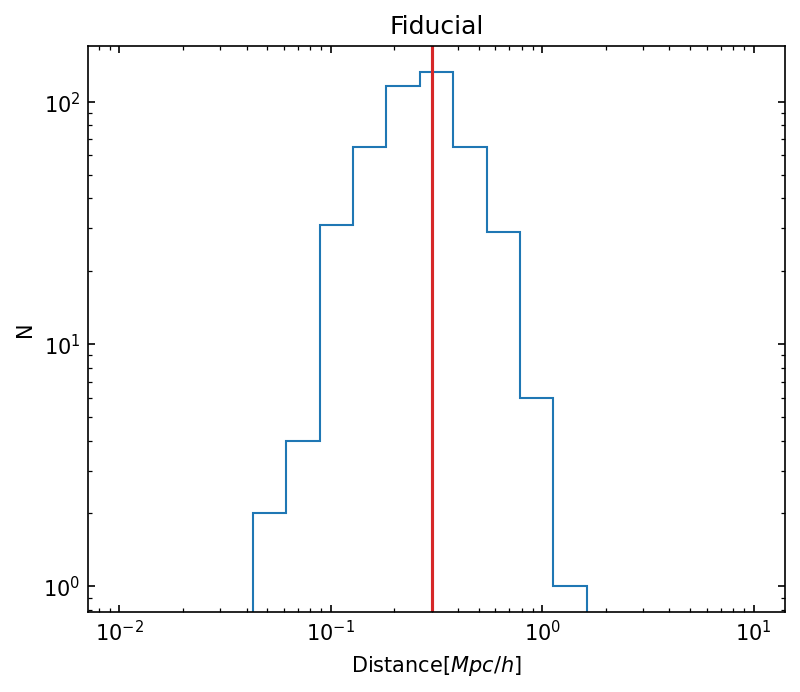

In [15]:
fig, ax = plt.subplots(dpi=150, figsize=(6,5))

ax.set_xscale('log')
ax.hist(dmatch, bins=np.logspace(-2,1,20), log=True, histtype='step')

ax.set_xlabel('Distance$[Mpc/h]$')
ax.set_ylabel('N')

plt.title('Fiducial')

ax.axvline(0.3, color='C3')

### Let's work in a specific region

We will focus on one of the zoom halos

In [16]:
Pzoom = zoom.fof['halo_pos'][psel][xmatch]
Pmtng = mtng.fof['halo_pos'][final_sel]

In [17]:
center = Pmtng[ihalo]

In [18]:
L_p = 5
z_slab = 5
xmin = np.array([center[0]-L_p/2,center[1]-L_p/2,center[2]-z_slab/2])

mtng_sel = np.where( (mtng.fof['halo_pos'][:,0]>(center[0]-L_p/2)) & (mtng.fof['halo_pos'][:,0]<(center[0]+L_p/2)) &\
                     (mtng.fof['halo_pos'][:,1]>(center[1]-L_p/2)) & (mtng.fof['halo_pos'][:,1]<(center[1]+L_p/2)) &\
                     (mtng.fof['halo_pos'][:,2]>(center[2]-z_slab/2)) & (mtng.fof['halo_pos'][:,2]<(center[2]+z_slab/2)) &\
                     (mtng.fof['halo_m200b']>0))[0]

In [19]:
zoom_grid = {}

part = ['dm', 'gas', 'stars']

for type in range(len(part)):
    zoom_sel = np.where( (getattr(zoom,part[type])['pos'][:,0]>(center[0]-L_p/2)) & (getattr(zoom,part[type])['pos'][:,0]<(center[0]+L_p/2)) &\
                        (getattr(zoom,part[type])['pos'][:,1]>(center[1]-L_p/2)) & (getattr(zoom,part[type])['pos'][:,1]<(center[1]+L_p/2)) &\
                        (getattr(zoom,part[type])['pos'][:,2]>(center[2]-z_slab/2)) & (getattr(zoom,part[type])['pos'][:,2]<(center[2]+z_slab/2)) )[0]

    zoom_grid[part[type]] = bacco.statistics.compute_mesh(pos=getattr(zoom, part[type])['pos'][zoom_sel] - xmin[np.newaxis,:], box=L_p, ngrid=512)

2024-08-27 14:43:43,429 bacco.sims : Read data for 14585879/116709822 particles...


/cosmos_storage/data_sharing/MN5_resims/fiducial/hydro_output/snapdir_264/snapshot_264.0.hdf5


2024-08-27 14:43:46,240 bacco.sims : Read data for 14585879/116709822 particles...
2024-08-27 14:43:46,286 bacco.sims : Read data for 14578720/116709822 particles...
2024-08-27 14:43:49,066 bacco.sims : Read data for 14578720/116709822 particles...
2024-08-27 14:43:49,108 bacco.sims : Read data for 14593202/116709822 particles...
2024-08-27 14:43:51,866 bacco.sims : Read data for 14593202/116709822 particles...
2024-08-27 14:43:51,902 bacco.sims : Read data for 14601069/116709822 particles...
2024-08-27 14:43:54,658 bacco.sims : Read data for 14601069/116709822 particles...
2024-08-27 14:43:54,707 bacco.sims : Read data for 14584295/116709822 particles...
2024-08-27 14:43:57,479 bacco.sims : Read data for 14584295/116709822 particles...
2024-08-27 14:43:57,521 bacco.sims : Read data for 14596339/116709822 particles...
2024-08-27 14:44:00,315 bacco.sims : Read data for 14596339/116709822 particles...
2024-08-27 14:44:00,355 bacco.sims : Read data for 14593119/116709822 particles...
2024

/cosmos_storage/data_sharing/MN5_resims/fiducial/hydro_output/snapdir_264/snapshot_264.0.hdf5


2024-08-27 14:44:10,791 bacco.sims : Read data for 760480/6126136 particles...
2024-08-27 14:44:10,960 bacco.sims : Read data for 760480/6126136 particles...
2024-08-27 14:44:11,019 bacco.sims : Read data for 775511/6126136 particles...
2024-08-27 14:44:11,175 bacco.sims : Read data for 775511/6126136 particles...
2024-08-27 14:44:11,241 bacco.sims : Read data for 777288/6126136 particles...
2024-08-27 14:44:11,398 bacco.sims : Read data for 777288/6126136 particles...
2024-08-27 14:44:11,477 bacco.sims : Read data for 758247/6126136 particles...
2024-08-27 14:44:11,653 bacco.sims : Read data for 758247/6126136 particles...
2024-08-27 14:44:11,723 bacco.sims : Read data for 739620/6126136 particles...
2024-08-27 14:44:11,899 bacco.sims : Read data for 739620/6126136 particles...
2024-08-27 14:44:11,968 bacco.sims : Read data for 761978/6126136 particles...
2024-08-27 14:44:12,159 bacco.sims : Read data for 761978/6126136 particles...
2024-08-27 14:44:12,217 bacco.sims : Read data for 7

ValueError: too many values to unpack (expected 3)

In [ ]:
sel_pos = (mtng.fof['halo_pos'][mtng_sel]-xmin[np.newaxis, :])/L_p * 512

/tmp/ipykernel_135820/379568341.py:16: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax[type, i].set_xticklabels(['{:.0f}'.format(xticklabels[i]) for i in range(len(xticklabels))])
/tmp/ipykernel_135820/379568341.py:17: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax[type, i].set_yticklabels(['{:.0f}'.format(yticklabels[i]) for i in range(len(yticklabels))])


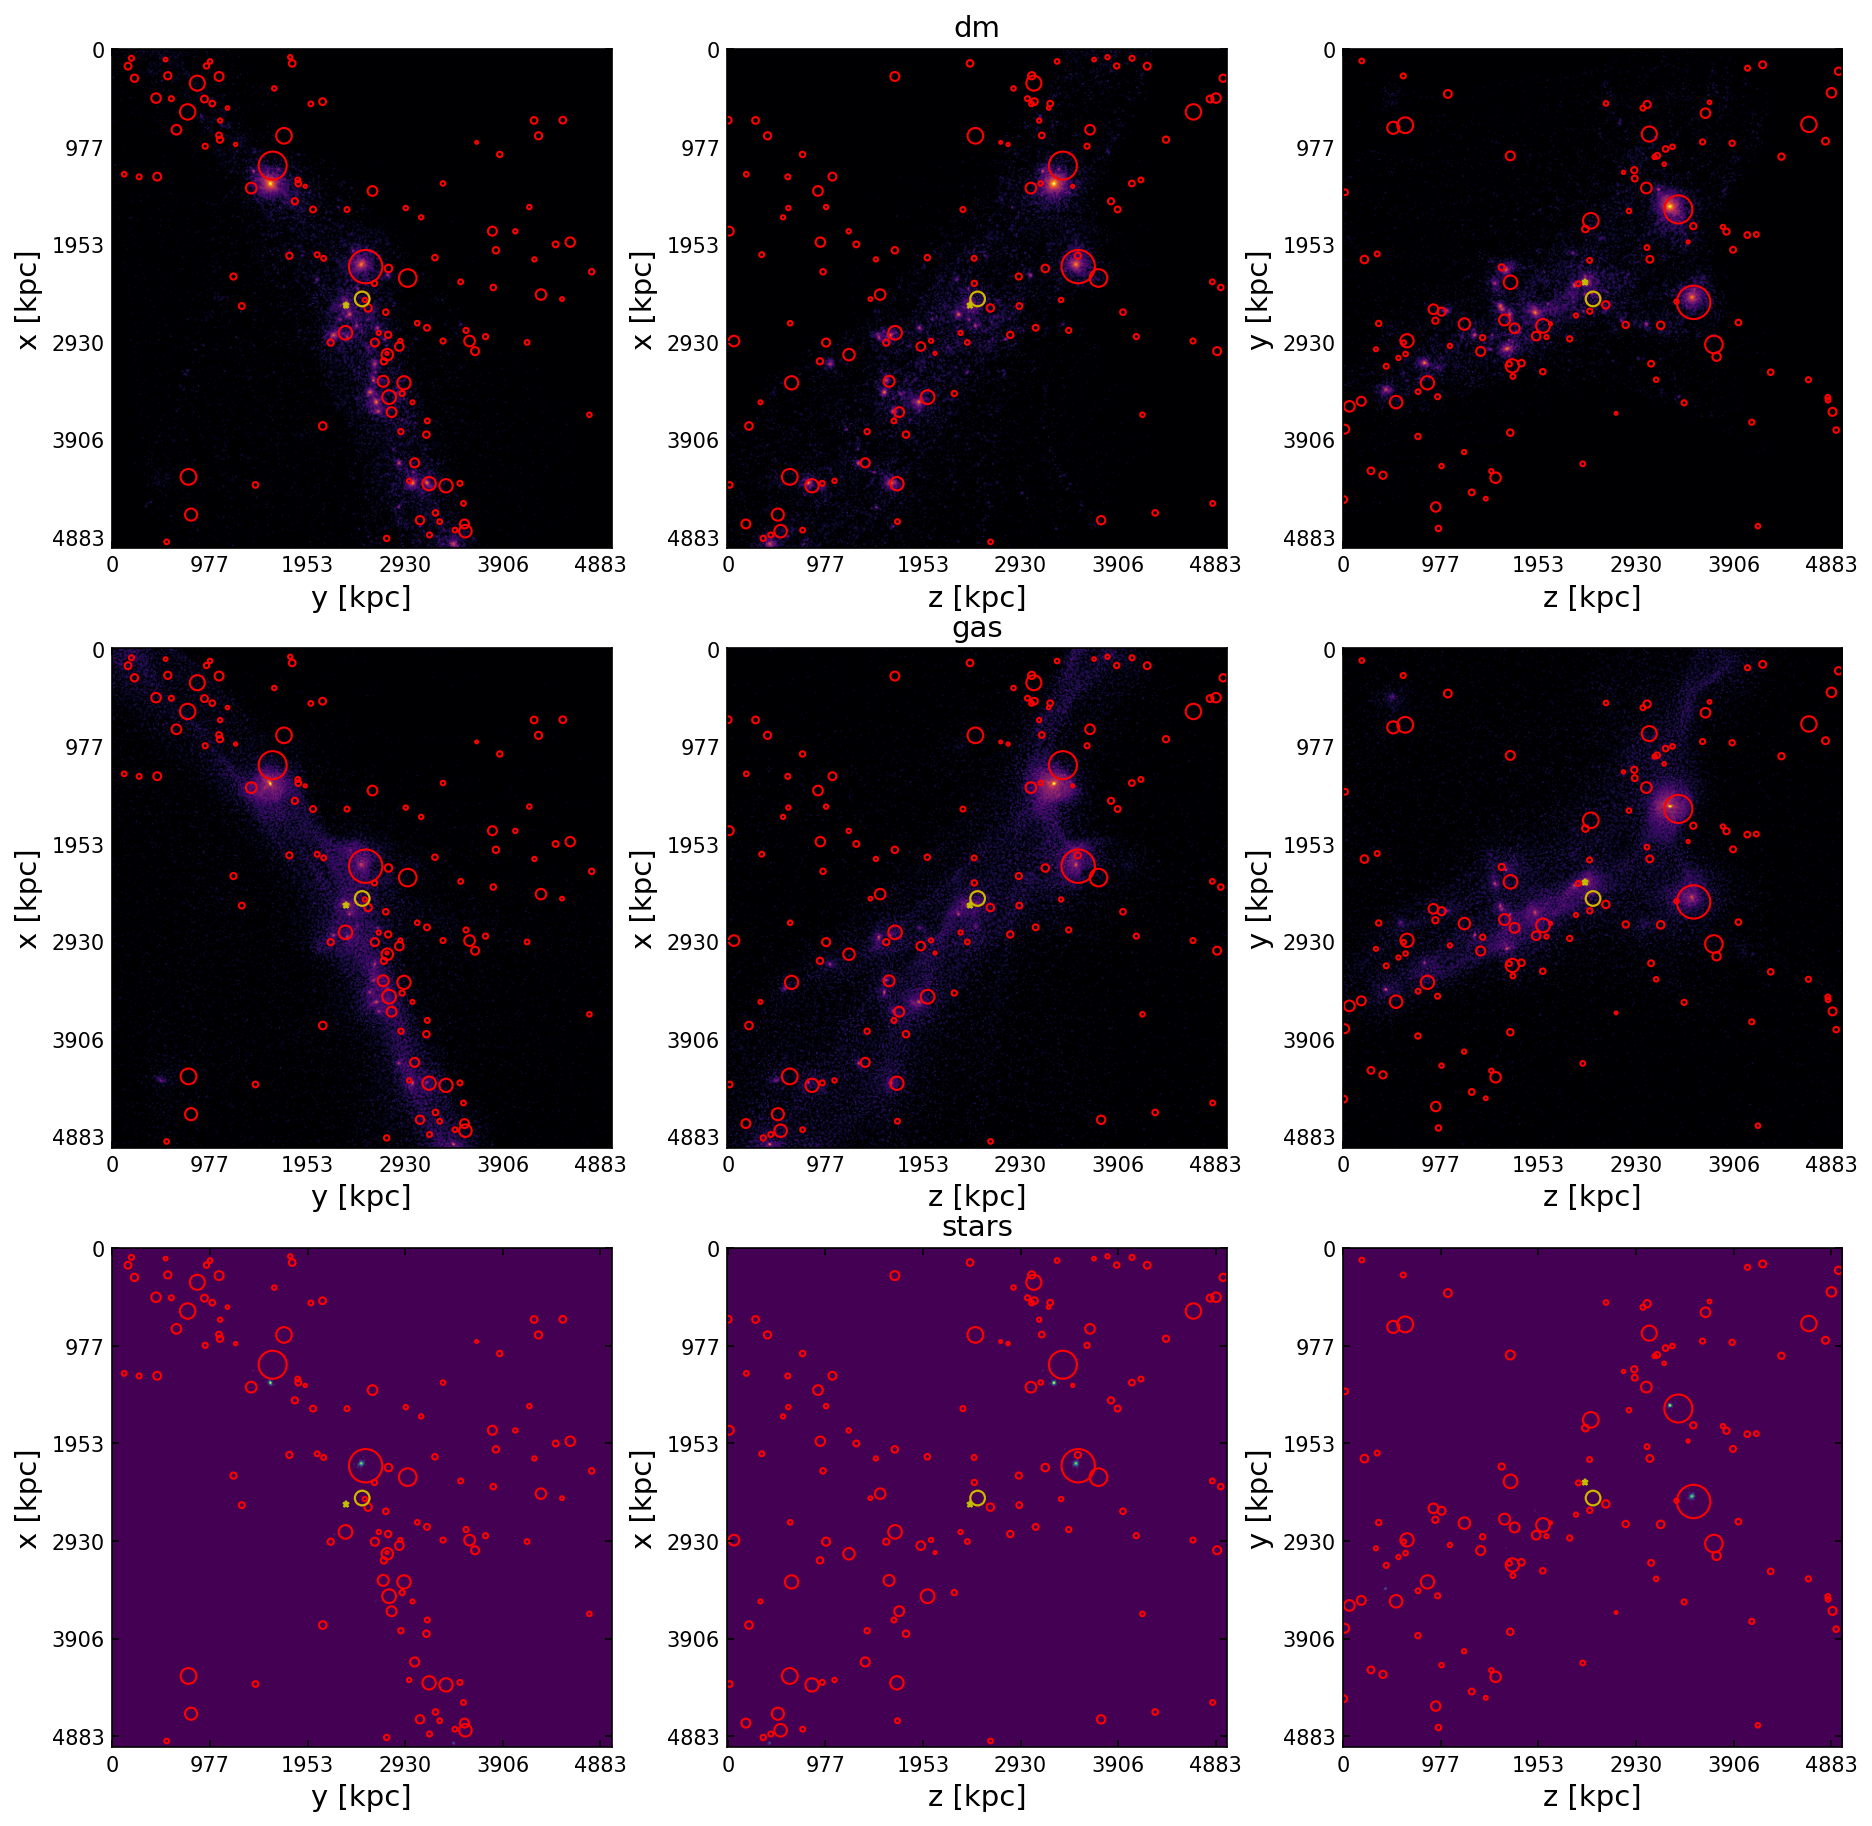

In [ ]:
Pmtng_norm = (Pmtng-xmin[np.newaxis, :])/L_p * 512
Pzoom_norm = (Pzoom-xmin[np.newaxis, :])/L_p * 512

fig, ax = plt.subplots(3, 3, dpi=150, figsize=(15,15))

cmap = ['inferno', 'inferno', 'viridis']

for type in range(len(part)):
    ax[type, 0].imshow(np.log10(1+np.sum(zoom_grid[part[type]][0,:,:,:],axis=2)), cmap=cmap[type])
    ax[type, 1].imshow(np.log10(1+np.sum(zoom_grid[part[type]][0,:,:,:],axis=1)), cmap=cmap[type])
    ax[type, 2].imshow(np.log10(1+np.sum(zoom_grid[part[type]][0,:,:,:],axis=0)), cmap=cmap[type])

    for i in range(3):
        xticklabels = 1000 * ax[type, i].get_xticks() / 512 * L_p
        yticklabels = 1000 * ax[type, i].get_yticks() / 512 * L_p
        ax[type, i].set_xticklabels(['{:.0f}'.format(xticklabels[i]) for i in range(len(xticklabels))])
        ax[type, i].set_yticklabels(['{:.0f}'.format(yticklabels[i]) for i in range(len(yticklabels))])

    ax[type, 0].set_xlabel('y [kpc]', fontsize=14)
    ax[type, 0].set_ylabel('x [kpc]', fontsize=14)

    ax[type, 1].set_xlabel('z [kpc]', fontsize=14)
    ax[type, 1].set_ylabel('x [kpc]', fontsize=14)

    ax[type, 2].set_xlabel('z [kpc]', fontsize=14)
    ax[type, 2].set_ylabel('y [kpc]', fontsize=14)

    ax[type, 1].set_title(part[type], fontsize=14)

    for i in range(sel_pos.shape[0]):
        circle = plt.Circle((sel_pos[i,1],sel_pos[i,0]), mtng.fof['halo_r200c'][mtng_sel][i]/L_p*512, color='r', fill=False)
        ax[type, 0].add_artist(circle)
        circle = plt.Circle((sel_pos[i,2],sel_pos[i,0]), mtng.fof['halo_r200c'][mtng_sel][i]/L_p*512, color='r', fill=False)
        ax[type, 1].add_artist(circle)
        circle = plt.Circle((sel_pos[i,2],sel_pos[i,1]), mtng.fof['halo_r200c'][mtng_sel][i]/L_p*512, color='r', fill=False)
        ax[type, 2].add_artist(circle)

    ax[type, 0].plot( Pzoom_norm[ihalo][1], Pzoom_norm[ihalo][0], 'y*', ms=3)
    ax[type, 1].plot( Pzoom_norm[ihalo][2], Pzoom_norm[ihalo][0], 'y*', ms=3)
    ax[type, 2].plot( Pzoom_norm[ihalo][2], Pzoom_norm[ihalo][1], 'y*', ms=3)

    circle = plt.Circle((Pmtng_norm[ihalo][1], Pmtng_norm[ihalo][0]), mtng.fof['halo_r200c'][final_sel][ihalo]/L_p*512, color='y', fill=False)
    ax[type, 0].add_artist(circle)
    circle = plt.Circle((Pmtng_norm[ihalo][2], Pmtng_norm[ihalo][0]), mtng.fof['halo_r200c'][final_sel][ihalo]/L_p*512, color='y', fill=False)
    ax[type, 1].add_artist(circle)
    circle = plt.Circle((Pmtng_norm[ihalo][2], Pmtng_norm[ihalo][1]), mtng.fof['halo_r200c'][final_sel][ihalo]/L_p*512, color='y', fill=False)
    ax[type, 2].add_artist(circle)

plt.savefig('../images/zoom_snap{:d}_{:d}_fid.pdf'.format(snap, ihalo), bbox_inches='tight')

### Save the cross-match

In [172]:
np.save("/lscratch/fgmaion/MTNG-resims/cross-match/xmatch_fid.npy", [{'xmatch':psel[xmatch], 'dmatch':dmatch}])